# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках) и пришлите `.ipynb` **с выполненными ячейками** и его PDF-экспорт (`File → Save and Export Notebook As → PDF` или `HTML → печать в PDF`). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../../lectures/lecture01/lecture01.md), [демо](../../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

**Ответ:**

Пусть $\{x \in \mathbb{R}^3, x = (x_1, x_2, x_3)$

 1. _Стандартная форма:_

 $min(f) = (x_1-1)^2 + (x_2-2)^2 + (x_3-3)^2$ (так как минимизация расстояния и его квадрата одна и та задача)

$g_1(x) = x_1+x_2+x_3+1=0$

$g_2(x) = x_1 - x_3 = 0$

 2. _Класс:_

 QP так как
 $min(f) = (x_1-1)^2 + (x_2-2)^2 + (x_3-3)^2 = x_1^2 - 2x_1 + x_2^2 - 4x_2 + x_3^2 - 6x_3 + 3 = 0.5x^TQx + c^Tx + d$

Q = \begin{pmatrix}
2 & 0 & 0\\
0 & 2 & 0\\
0 & 0 & 2
\end{pmatrix}

3. _Ограничения_: есть (ограничения-равенства)

4. Выпуклость: выпукла, так как Q - положительно-определена

In [6]:
a = np.array([1.0, 2.0, 3.0])

def f(x):
    return np.sum((x - a) ** 2)

def grad_f(x):
    return 2.0 * (x - a)

constraints = [
    {'type': 'eq', 'fun': lambda x: x[0] + x[1] + x[2] - 1.0},
    {'type': 'eq', 'fun': lambda x: x[0] - x[2]},
]

x0 = np.array([0.0, 0.0, 0.0])
res = minimize(
    f,
    x0,
    jac=grad_f,
    method='SLSQP',
    constraints=constraints,
    options={'ftol': 1e-12, 'maxiter': 1000}
)

print("x =", res.x)
print("f(x) =", res.fun)
print("Distance: ", np.sqrt(res.fun))

x = [0.33333333 0.33333333 0.33333333]
f(x) = 10.333333333333332
Distance:  3.214550253664318


**(б)**

**Ответ:**
1. x = (x_1,...,x_n), где x - количество продуктов каждого из n типов, которые нам нужно купить. $x \in R^n$
2. Стандартная форма:

Общая стоимость всех продуктов: f = $c_1*x_1+...+c_n*x_n$

Ограничения: (количество вещества i) = $A_{i1}*x_1 + ... + A_{in}*x_n >= b_i, i = {1,m}$

В матричной форме стандартная форма: f = $c^Tx$, Ax>=b $(h_1 = Ax), x>=0 (h_2 = x)$, g(x) = пустое множество

3. Класс
LP, так как функции линейные (целевая и ограничения)
3. Ограничения: есть ограничения-неравенства
4. Выпуклость: да, LP - всегда выпукла

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**Ответ:**
1. Пусть вершины прямоугольника $(x_1,x_2), (-x_1, x_2), (x_1, -x_2), (-x_1, -x_2)$, тогда задача найти x = $(x_1, x_2)$ >= 0, $x \in R^2$

2. Стандартная форма:

Ограничение (внутри круга): $x_1^2+x_2^2<=1$ => $h(x) = 1- x_1^2-x_2^2 >= 0$
Функция площади: f(x) = $-4x_1x_2$ (- так как задача максимизации)

стандартная форма: f(x) = $-4x_1x_2$, $h1(x) = 1- x_1^2-x_2^2 >= 0$, $h2(x) = x_1 >= 0$, $h3(x) = x_2 >= 0$

3. Класс
Квадратичная с квадратичными ограничениями: QCQP

4. Ограничения: есть ограничения-неравенства

5. Выпуклость: матрица целевой функции не является положительно-опредленной, пожтому невыпукла
\begin{pmatrix}
0 & -4\\
-4 & 0
\end{pmatrix}
собственные 4 и -4 - разные знаки => не является положительно-опредленной

_Найдем площадь_

S =  $4x_1x_2$

$x_1^2+x_2^2 x<= 1$

$(x_1-x_2)^2 >= 0$ => $x_1^2+x_2^2 >= 2x_1*x_2$

$x_1x_2$ <= 0.5

S=$4x_1x_2$<= 4*0.5 <=2

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.**(г)**

**Ответ:**
1. x = (x_1,x_2, x_3), $x \in R^3$

навязка r =  $\varphi(t; x) - y_i$, где y - истинное значение

2. Стандартная форма:

f = $\sum{x_1 \sin(x_2 t + x_3) - y_i}^2$ (задача минимизации)

g(x) = h(x) = пустое множество

3. Класс
NLP, так как функции произвольные
3. Ограничения: нет
4. Выпуклость: невыпуклая (нелинейный МНК)

**(д, бонус)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**Ответ:**
Вводим дополнительную переменную s

s>=$|a_i^\top x - b_i|$ для каждого i => $-s<=a_i^\top x - b_i<=s $ для каждого i

$a_i^\top x - b_i + s => 0$

$- a_i^\top x + b_i + s => 0$

s - верхняя граница всех ошибок, s = $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$

2. Итого стандартная форма:
$min(s)$ при ограничениях {f(x) = s}

$a_i^\top x - b_i + s => 0$ {это h_1}

$- a_i^\top x + b_i + s => 0$ {это h_2}
{g(x) - пустое множество}

3. Класс LP, потому что f(x) = s - линейная и ограничения тоже линейные
4. Ограничения: есть, ограничения-неравенства
5. Выпуклая, так как LP

## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

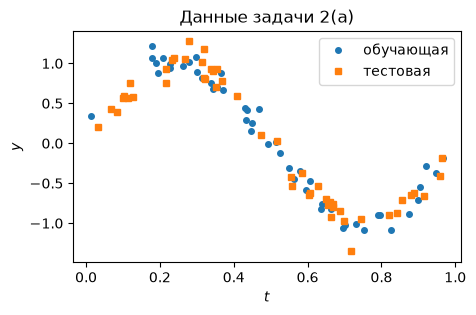

In [7]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

In [9]:
def design(t, deg):
    return np.vander(t, deg + 1, increasing=True)

degrees = range(1, 16)
mse_train = []
mse_test = []

for d in degrees:
    A_train = design(t_train, d)
    A_test = design(t_test, d)
    x_lstsq, *_ = np.linalg.lstsq(A_train, y_train, rcond=None)
    y_train_pred = A_train @ x_lstsq
    y_test_pred = A_test @ x_lstsq
    mse_train.append(np.mean((y_train - y_train_pred) ** 2))
    mse_test.append(np.mean((y_test - y_test_pred) ** 2))

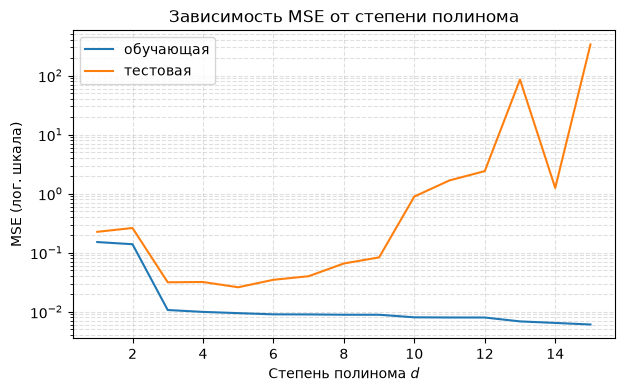

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(degrees, mse_train, label="Train")
plt.plot(degrees, mse_test, label="Test")
plt.yscale("log")
plt.xlabel("Степень полинома $d$")
plt.ylabel("MSE")
plt.title("Зависимость MSE от степени полинома")
plt.legend()
plt.show()

**Ответ:** График ошибки на обучающей выборке убывает сначала резко, далее монотонно снижается, потому что сначала идет обучение на данных, далее с ростом степени получается более сложный полином, который способен подстраиваться точно под точки всей обучающей выборки. В итоге получаем идеально подходящую под точки кривую. График ошибки тестовой выборки сничала убывает, потом возрастает. Рост ошибки происходит из-за переобучения. Чем выше степень полинома, тем точнее он подходит под точки обучающей выборки, но тем больше теряет способность к обобщению.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [11]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [18]:
A_ub = -A
b_ub = -b

res = linprog(c, A_ub=A_ub, b_ub=b_ub,
              bounds=(0, None), method="highs")
res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=(0, None), method="highs")
print("статус :", res.message)
print("x*     =", res.x.round(6), "  прибыль =", round(res.fun, 6))   # минус: возвращаемся к max
print("slack  =", res.slack.round(6), "  (b - A x*: невязка каждого неравенства)")
for i, s in enumerate(res.slack, 1):
    print(f"   ограничение {i}: {'активно' if abs(s) < 1e-9 else 'неактивно, запас %.2f' % s}")


статус : Optimization terminated successfully. (HiGHS Status 7: Optimal)
x*     = [ 2.  4. -0.  0.]   прибыль = 16.0
slack  = [0. 0. 0.]   (b - A x*: невязка каждого неравенства)
   ограничение 1: активно
   ограничение 2: активно
   ограничение 3: активно


In [19]:
b_new = b.copy()
b_new[0] += 1.0
A_ub = -A
b_ub = -b_new
res = linprog(c, A_ub=A_ub, b_ub=b_ub,bounds=(0, None), method="highs")
print("статус :", res.message)
print("x*     =", res.x.round(6), "  прибыль =", round(res.fun, 6))   # минус: возвращаемся к max
print("slack  =", res.slack.round(6), "  (b - A x*: невязка каждого неравенства)")
for i, s in enumerate(res.slack, 1):
    print(f"   ограничение {i}: {'активно' if abs(s) < 1e-9 else 'неактивно, запас %.2f' % s}")


статус : Optimization terminated successfully. (HiGHS Status 7: Optimal)
x*     = [1.888889 3.555556 0.       0.666667]   прибыль = 17.111111
slack  = [0. 0. 0.]   (b - A x*: невязка каждого неравенства)
   ограничение 1: активно
   ограничение 2: активно
   ограничение 3: активно


**Ответ:** Набор активных ограничений не изменился, снизилось число закупок 1 и 2 товара, увеличилось число 4 товара. прибыль возросла